<a href="https://colab.research.google.com/github/SteTerro/Neural-Network-from-Scratch/blob/main/NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Network

This project consists of the implementation of a Neural Network from scratch. The Neural Network implemented here was based on the one published in this [IBM article](https://developer.ibm.com/articles/neural-networks-from-scratch/). Starting from this as a foundation, several improvements were made, such as the ability to modify the number of Hidden Layers, the implementation of various activation functions, and the capability to solve different types of problems: Regression, Binary Classification, and Multiclass Classification. All these types of problems were subsequently tested. The project is divided as follows:

*   **Chapter 1:** Neural Network Presentation
*   **Chapter 2:** Regression Problem
*   **Chapter 3:** Binary Classification
*   **Chapter 4:** Multiclass Classification on the `NIST Dataset`





## Chapter 1

This section will explain the implementation of the Neural Network (NN), detailing all the various implementation choices made.

---

The first step is to import the libraries. The only library fundamental to the NN's operation is numpy. The time and copy libraries are also imported; these are not essential for the structure's functioning but are used to measure the training time of each batch and to copy the best weights during training (see the train method).

The sklearn libraries is also imported, which will be used to prepare the datasets for training.

In [ ]:
from sklearn.datasets import fetch_openml
import polars as pl
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import copy

The `NeuralNetwork` class accepts the following arguments:

*   *problem_type:* the type of problem the Neural Network must solve. It can be of three types: regression, binary classification (bin\_classification), or multiclass classification (multi\_classification);
*   *activation:* the type of activation function for the Hidden Layers. The implemented activation functions are *ReLU* and *Sigmoid*;
*   *epochs:* the number of complete passes of the entire training dataset through the learning algorithm. The default is 40;
*   *l_rate:* the learning rate for the algorithm. The default is *0.001*. Higher values showed a strong tendency towards overshooting.

### Activation FUnction sigmoid, ReLU e Softmax

```
    def sigmoid (self, Z, derivative=False):
        if derivative:
            return self.sigmoid(Z) * (1 - self.sigmoid(Z))
        return 1/(1 + np.exp(-Z))
    
    def ReLU(self, Z, derivative=False):
        if derivative:
            return Z > 0
        return np.maximum(Z, 0)
```
These are the implementations of the various activation functions that can be chosen in the neural network. The ReLU function can only be used in the hidden layers. The Sigmoid function can be used in the hidden layers and is used as the activation function for the output layer for binary classification, although the Softmax function with a number of classes equal to 2 can be used in its place.

```
    def softmax(self, Z):
        A = np.exp(Z) / sum(np.exp(Z))
        return A
```

The Softmax function is used for multiclass classification. Since it is not used in the hidden layers, its derivative was not implemented.

### Inizialization
```
    def initialization(self):
        A = [0] * len(self.sizes)
        Z = [0] * len(self.sizes)
        W = []
        B = []

        for i in range(1, len(self.sizes)):
            w = np.random.uniform(-0.05, 0.05, (self.sizes[i], self.sizes[i-1]))
            W.append(w)
            
            if self.activation == "ReLU":
                b = np.full(self.sizes[i], 0.01)
            else:
                b = np.zeros(self.sizes[i])
            B.append(b)

        return W, A, Z, B
```
In the initialization method, the parameters that will be used in the NN are initialized. The weights vector is initialized with values ranging between *-0.05* and *0.05*. The bias vector is initialized with all zeros if the activation function is Sigmoid, or with values equal to *0.01* if the activation function is ReLU to avoid ReLU death. Vectors for A and Z are also created.

### Forward propagation
This method implements the forward phase (or forward pass).
Let the following be:
- A: Activation matrix
- Z: Pre-activation (o Net Input) matrix
```
def forward_pass(self, x_train):
```
I start by inserting the raw data into the first layer of the network.
```
        self.A[0] = x_train
```
Next, for each hidden layer, I begin the activation phase. I initially calculate Z through a linear transformation as:

*Z = Weight * A + bias*

and then I apply an activation function (*sigmoid* o *ReLU*).
```
        for i in range(1, len(self.sizes)-1):
            self.Z[i] = np.dot(self.W[i-1], self.A[i-1]) + self.B[i-1]
            if self.activation == "ReLU":
                self.A[i] = self.ReLU(self.Z[i])
            elif self.activation == "sigmoid":
                self.A[i] = self.sigmoid(self.Z[i])
            else:
                raise ValueError("Unsupported activation function")
```
Finally, I repeat the same operation for the output layer as well. In this case, the activation functions change based on the type of problem to be solved: The Softmax function is used for multiclass classification, The Sigmoid function is used for binary classification, and finally, for regression problems, the identity activation function is used, which is equivalent to not using any activation function
```
        self.Z[-1] = np.dot(self.W[-1], self.A[-2]) + self.B[-1]
        if self.problem_type == "bin_classification":
            self.A[-1] = self.sigmoid(self.Z[-1])
        elif self.problem_type == "multi_classification":
            self.A[-1] = self.softmax(self.Z[-1])
        elif self.problem_type == "regression":
            self.A[-1] = self.Z[-1]
        else:
            raise ValueError("Unsupported problem type")
```
Finally, I return the last value of A.
```
        return self.A[-1]
```

### Backpropagation
The method implements stochastic backpropagation. This phase acts in reverse, meaning it starts from the last layer and propagates the errors back through the network. I begin by creating the vectors that will contain the modified values for weights and biases.

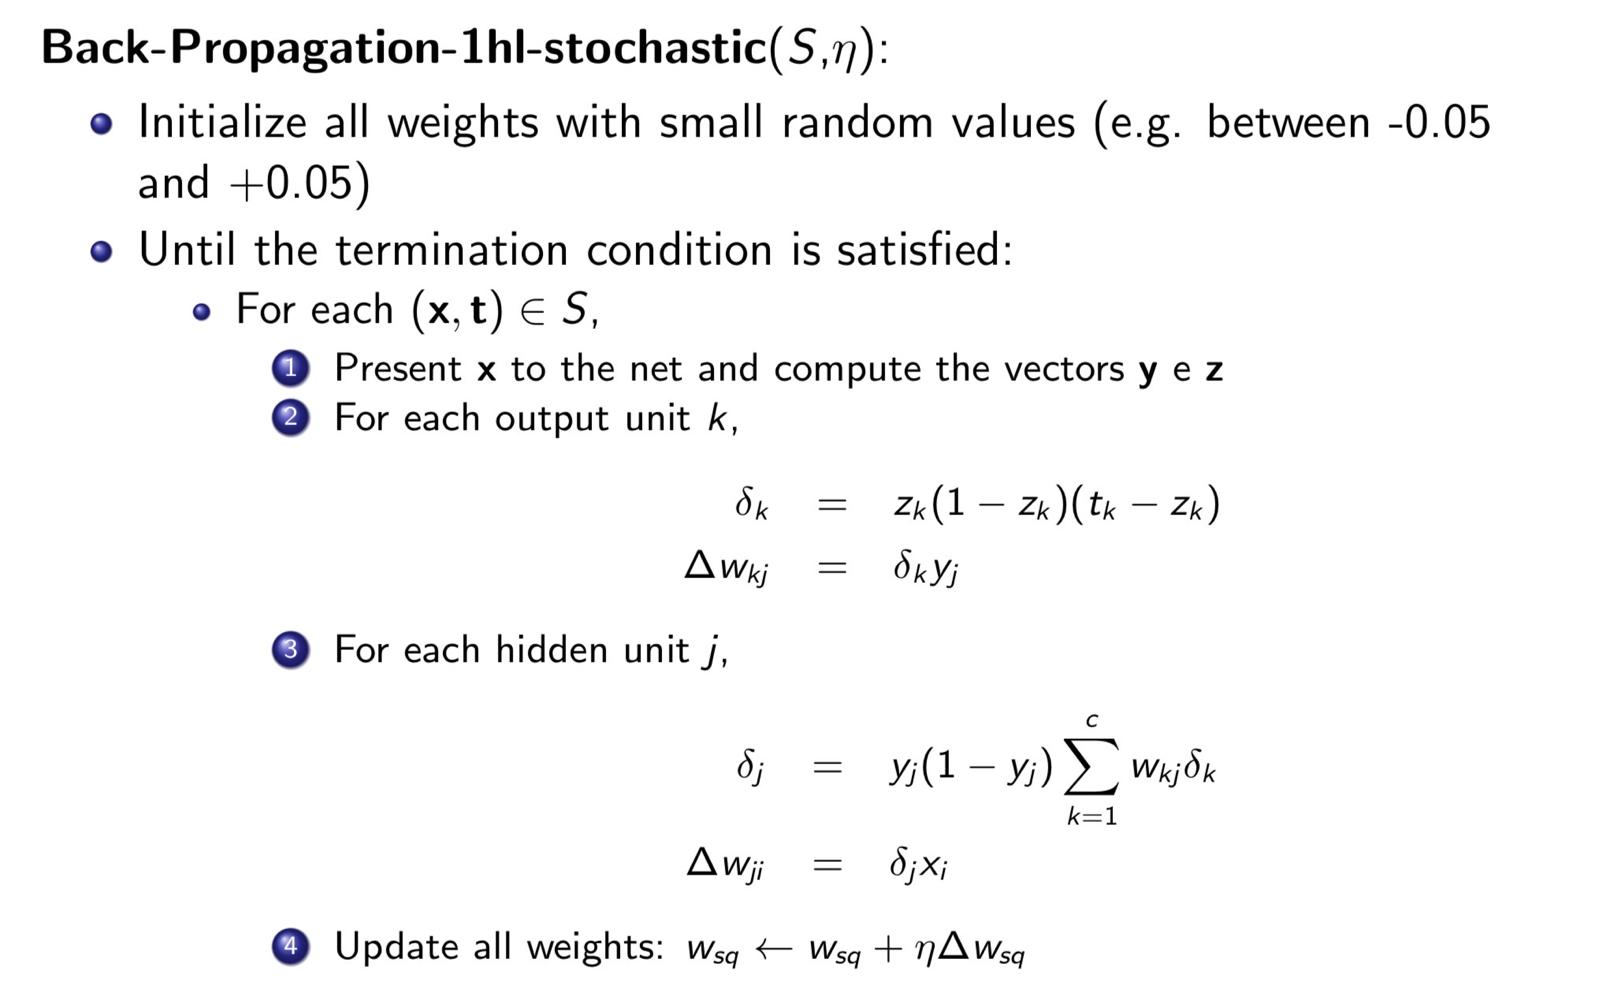

```
def backward_pass(self, y_train, output):
        change_w = []
        change_b = []
```
I start by calculating the difference between what the network has predicted and the actual value, which is $δ_k$. Subsequently, I calculate the updated weights of the last layer, which is $Δw_{kj}$.

```
        error = output - y_train
        change_w.append(np.outer(error, self.A[-2]))
        change_b.append(error)
```
Next, I iterate through every hidden layer and calculate $δ_j$ and $Δw_{ji}$. I repeat this for every layer, and finally return the updated values.
```
        for i in range(len(self.sizes)-2, 0, -1):
            if self.activation == "ReLU":
                error = np.dot(self.W[i].T, error) * self.ReLU(self.Z[i], derivative=True)
            elif self.activation == "sigmoid":
                error = np.dot(self.W[i].T, error) * self.sigmoid(self.Z[i], derivative=True)
            else:
                raise ValueError("Unsupported activation function")
            change_w.append(np.outer(error, self.A[i-1]))
            change_b.append(error)

        return change_w, change_b
```

### Updating Weights and Biases
This method is responsible for updating the weights and biases of the network. This is done according to the formula:

$ W_{new} = W_{old} - l\_rate \times \Delta W$
```
    def update_network_parameters(self, changes_to_w, changes_to_b):
        changes_to_w.reverse()
        changes_to_b.reverse()
        for i, (change_w, change_b) in enumerate(zip(changes_to_w, changes_to_b)):
            self.B[i] -= self.l_rate * change_b
            self.W[i] -= self.l_rate * change_w
```

### Evaluation
This method is responsible for calculating evaluation metrics for the neural network. For classification problems, accuracy is measured. For regression problems, the Mean Squared Error (MSE) is calculated.
```
    def compute_accuracy(self, x_val, y_val):
        predictions = []

        for x, y in zip(x_val, y_val):
            output = self.forward_pass(x)
            if self.problem_type == "multi_classification":
                pred = np.argmax(output)
                predictions.append(pred == np.argmax(y))
            elif self.problem_type == "bin_classification":
                pred = 1 if output >= 0.5 else 0
                predictions.append(pred == y)
            elif self.problem_type == "regression":
                predictions.append(np.mean((output.flatten() - y.flatten()) ** 2))

        return np.mean(predictions)
```
### Training
This method handles the training of the neural network. First, the values related to time measurement are initialized, as well as the values that will store the best accuracy, weights, and biases during training. It was decided to implement these backup values because the network showed a tendency towards overshooting during the training phases. This solution is intended to allow for a quick recovery of the values that proved to be the best during training.
```
    def train(self, x_train, y_train, x_val, y_val):
        start_time = time.time()
        best_accuracy = float('inf')
        best_weights = None
        best_biases = None
```
For each iteration, the estimate is calculated using the `forward_pass` method. Subsequently, the new weights and biases are calculated using backpropagation with the `backward_pass` and `update_network_parameters` methods.
```
        for iteration in range(self.epochs):
            for x,y in zip(x_train, y_train):
                output = self.forward_pass(x)
                changes_to_w, changes_to_b = self.backward_pass(y, output)
                self.update_network_parameters(changes_to_w, changes_to_b)
```
Subsequently, I calculate the accuracy (or the MSE in the case of regression). And if the new accuracy is better than the previous one, I save the corresponding weights and biases.
```
            accuracy = self.compute_accuracy(x_val, y_val)
            if self.verbose:
                print('Epoch: {0}, Time Spent: {1:.2f}s, Accuracy: {2}'.format(
                    iteration+1, time.time() - start_time, accuracy
                ))
            if self.problem_type == "regression":
                if accuracy < best_accuracy:
                    best_accuracy = accuracy
                    best_weights = copy.deepcopy(self.W)
                    best_biases = copy.deepcopy(self.B)
            else:
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_weights = copy.deepcopy(self.W)
                    best_biases = copy.deepcopy(self.B)
```
Finally, I retrieve the best weights and best biases and print them to the screen. The training phase is thus finished.
```
        if best_weights is not None:
            self.W = best_weights
            self.B = best_biases
        print("Training completed. Best accuracy/mse:", best_accuracy)
```
### Prediction
This method handles the prediction of new values. I use the `forward_pass` method to obtain the predicted values.
```
    def predict(self, input_data):
        predictions = []
        
        for x in input_data:
            output = self.forward_pass(x)
            
            if self.problem_type == "regression":
                predictions.append(output)
                
            elif self.problem_type == "bin_classification":
                pred = 1 if output >= 0.5 else 0
                predictions.append(pred)
                
            elif self.problem_type == "multi_classification":
                pred = np.argmax(output)
                predictions.append(pred)
                
        return np.array(predictions)
```

In [ ]:
class NeuralNetwork():
    def __init__(self, sizes, problem_type, activation, epochs=40, l_rate=0.001, VERBOSE=False):
        self.sizes = sizes
        self.problem_type = problem_type
        self.activation = activation
        self.epochs = epochs
        self.l_rate = l_rate
        self.verbose = VERBOSE

        self.W, self.A, self.Z, self.B = self.initialization()

        if self.problem_type == "regression" or self.problem_type == "bin_classification":
            self.sizes[-1] = 1

    def sigmoid (self, Z, derivative=False):
        if derivative:
            return self.sigmoid(Z) * (1 - self.sigmoid(Z))
        return 1/(1 + np.exp(-Z))

    def ReLU(self, Z, derivative=False):
        if derivative:
            return Z > 0
        return np.maximum(Z, 0)

    def softmax(self, Z):
        A = np.exp(Z) / sum(np.exp(Z))
        return A

    def initialization(self):
        A = [0] * len(self.sizes)
        Z = [0] * len(self.sizes)
        W = []
        B = []

        for i in range(1, len(self.sizes)):
            w = np.random.uniform(-0.05, 0.05, (self.sizes[i], self.sizes[i-1]))
            W.append(w)

            if self.activation == "ReLU":
                b = np.full(self.sizes[i], 0.01)
            else:
                b = np.zeros(self.sizes[i])
            B.append(b)

        return W, A, Z, B

    def forward_pass(self, x_train):
        self.A[0] = x_train

        for i in range(1, len(self.sizes)-1):
            self.Z[i] = np.dot(self.W[i-1], self.A[i-1]) + self.B[i-1]
            if self.activation == "ReLU":
                self.A[i] = self.ReLU(self.Z[i])
            elif self.activation == "sigmoid":
                self.A[i] = self.sigmoid(self.Z[i])
            else:
                raise ValueError("Unsupported activation function")

        self.Z[-1] = np.dot(self.W[-1], self.A[-2]) + self.B[-1]

        if self.problem_type == "bin_classification":
            self.A[-1] = self.sigmoid(self.Z[-1])
        elif self.problem_type == "multi_classification":
            self.A[-1] = self.softmax(self.Z[-1])
        elif self.problem_type == "regression":
            self.A[-1] = self.Z[-1]
        else:
            raise ValueError("Unsupported problem type")

        return self.A[-1]

    def backward_pass(self, y_train, output):
        change_w = []
        change_b = []

        error = output - y_train
        change_w.append(np.outer(error, self.A[-2]))
        change_b.append(error)

        for i in range(len(self.sizes)-2, 0, -1):
            if self.activation == "ReLU":
                error = np.dot(self.W[i].T, error) * self.ReLU(self.Z[i], derivative=True)
            elif self.activation == "sigmoid":
                error = np.dot(self.W[i].T, error) * self.sigmoid(self.Z[i], derivative=True)
            else:
                raise ValueError("Unsupported activation function")
            change_w.append(np.outer(error, self.A[i-1]))
            change_b.append(error)

        return change_w, change_b

    def update_network_parameters(self, changes_to_w, changes_to_b):
        changes_to_w.reverse()
        changes_to_b.reverse()
        for i, (change_w, change_b) in enumerate(zip(changes_to_w, changes_to_b)):
            self.B[i] -= self.l_rate * change_b
            self.W[i] -= self.l_rate * change_w

    def compute_accuracy(self, x_val, y_val):
        predictions = []

        for x, y in zip(x_val, y_val):
            output = self.forward_pass(x)
            if self.problem_type == "multi_classification":
                pred = np.argmax(output)
                predictions.append(pred == np.argmax(y))
            elif self.problem_type == "bin_classification":
                pred = 1 if output >= 0.5 else 0
                predictions.append(pred == y)
            elif self.problem_type == "regression":
                predictions.append(np.mean((output.flatten() - y.flatten()) ** 2))

        return np.mean(predictions)

    def train(self, x_train, y_train, x_val, y_val):
        start_time = time.time()
        if self.problem_type == "regression":
            best_accuracy = float('inf')
        else:
            best_accuracy = 0
        best_weights = None
        best_biases = None

        for iteration in range(self.epochs):
            for x,y in zip(x_train, y_train):
                output = self.forward_pass(x)
                changes_to_w, changes_to_b = self.backward_pass(y, output)
                self.update_network_parameters(changes_to_w, changes_to_b)

            accuracy = self.compute_accuracy(x_val, y_val)
            if self.verbose:
                print('Epoch: {0}, Time Spent: {1:.2f}s, Accuracy: {2}'.format(
                    iteration+1, time.time() - start_time, accuracy
                ))
            if self.problem_type == "regression":
                if accuracy < best_accuracy:
                    best_accuracy = accuracy
                    best_weights = copy.deepcopy(self.W)
                    best_biases = copy.deepcopy(self.B)
            else:
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_weights = copy.deepcopy(self.W)
                    best_biases = copy.deepcopy(self.B)

        if best_weights is not None:
            self.W = best_weights
            self.B = best_biases
        print("Training completed. Best accuracy/mse:", best_accuracy)

    def predict(self, input_data):
        predictions = []

        for x in input_data:
            output = self.forward_pass(x)

            if self.problem_type == "regression":
                predictions.append(output)

            elif self.problem_type == "bin_classification":
                pred = 1 if output >= 0.5 else 0
                predictions.append(pred)

            elif self.problem_type == "multi_classification":
                pred = np.argmax(output)
                predictions.append(pred)

        return np.array(predictions)

## Chapter 2: Regression

In this chapter, the neural network will be tested on a regression problem. We start by reading the data. The chosen dataset concerns the price of houses for sale:

In [ ]:
x, y = fetch_openml("house_prices", return_X_y=True, as_frame=True)

Let's print the first 5 values for x and y. We note that x contains categorical and numerical features, and that there are missing values. We proceed to create dummy variables and remove the missing values.

In [ ]:
print(x.head())
x = pd.get_dummies(x, drop_first=True)
x = x.dropna()
print("Shape of x:", x.shape)

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC Fence MiscFeature  \
0         Lvl    AllPub  ...           0        0    NaN   NaN         NaN   
1         Lvl    AllPub  ...           0        0    NaN   NaN         NaN   
2         Lvl    AllPub  ...           0        0    NaN   NaN         NaN   
3         Lvl    AllPub  ...           0        0    NaN   NaN         NaN   
4         Lvl    AllPub  ...           0        0    NaN   NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0       0      2    2008        WD

Let's print the first 5 values of y, which contains the house prices. Since this is a regression problem, y must have the dimension $n \times 1$. We modify the shape of y and verify its dimension. Having potentially removed observations in x, we also proceed to adjust the indices of y.

In [ ]:
print(y.head())
y = y.values.reshape(-1, 1)
y = y[x.index]
print("Shape of y:", y.shape)

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64
Shape of y: (1121, 1)


We select 10 random observations and remove them from the original dataset. We will use them later to verify the quality of the neural network.

In [ ]:
random_indices = np.random.choice(len(x), size=10, replace=False)
x_val = x.iloc[random_indices].values
y_val = y[random_indices]
x = x.drop(x.index[random_indices]).values
y = np.delete(y, random_indices, axis=0)

Now we will create the different train and test datasets. We will use the train_test_split function from `sklearn`.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(888, 246) (223, 246) (888, 1) (223, 1)


We will standardize our data using `StandardScaler()`.

In [ ]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)
x_val = scaler_x.transform(x_val)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

Starting from the *Universal Approximation Theorem*, let's begin by implementing a network with only one hidden layer.

In [ ]:
dnn_singlelayer = NeuralNetwork(
    sizes=[x.shape[1], 512, y.shape[1]],
    problem_type="regression",
    activation="ReLU",
    epochs=40,
    l_rate=0.001,
    VERBOSE = True
)

dnn_singlelayer.train(X_train, y_train, X_test, y_test)

Epoch: 1, Time Spent: 0.86s, Accuracy: 0.218534688679831
Epoch: 2, Time Spent: 1.81s, Accuracy: 0.2068361098807546
Epoch: 3, Time Spent: 2.82s, Accuracy: 0.21104308347832781
Epoch: 4, Time Spent: 3.66s, Accuracy: 0.2141688835153401
Epoch: 5, Time Spent: 4.63s, Accuracy: 0.21441050587891544
Epoch: 6, Time Spent: 6.12s, Accuracy: 0.2138659895049031
Epoch: 7, Time Spent: 8.09s, Accuracy: 0.2131621196937256
Epoch: 8, Time Spent: 8.89s, Accuracy: 0.21235996401181342
Epoch: 9, Time Spent: 9.76s, Accuracy: 0.21136377802208925
Epoch: 10, Time Spent: 10.49s, Accuracy: 0.21060373650017278
Epoch: 11, Time Spent: 11.15s, Accuracy: 0.20998819322668358
Epoch: 12, Time Spent: 11.61s, Accuracy: 0.20939402453838823
Epoch: 13, Time Spent: 12.07s, Accuracy: 0.20881063307128425
Epoch: 14, Time Spent: 12.53s, Accuracy: 0.20821163960045852
Epoch: 15, Time Spent: 12.99s, Accuracy: 0.20779749154463587
Epoch: 16, Time Spent: 13.45s, Accuracy: 0.20735500852522545
Epoch: 17, Time Spent: 13.92s, Accuracy: 0.20703

I calculate the predicted values using the `predict` method. I then compare them with the y_val values.


In [ ]:
preds = dnn_singlelayer.predict(x_val)
preds = scaler_y.inverse_transform(preds.reshape(-1, 1)).flatten()
y_val = y_val.flatten()

print("Comparing Predictions vs. Actual Values:")
for i, (pred, real) in enumerate(zip(preds, y_val)):
    print(f"Sample {i+1}: Predicted = {pred:.4f}, Real = {real:.4f}, Error = {abs(pred - real):.4f}")

Comparing Predictions vs. Actual Values:
Sample 1: Predicted = 104701.9791, Real = 110000.0000, Error = 5298.0209
Sample 2: Predicted = 164129.1870, Real = 180000.0000, Error = 15870.8130
Sample 3: Predicted = 265857.3448, Real = 264561.0000, Error = 1296.3448
Sample 4: Predicted = 430035.7223, Real = 437154.0000, Error = 7118.2777
Sample 5: Predicted = 341600.6047, Real = 403000.0000, Error = 61399.3953
Sample 6: Predicted = 144474.2177, Real = 115000.0000, Error = 29474.2177
Sample 7: Predicted = 267385.5770, Real = 255000.0000, Error = 12385.5770
Sample 8: Predicted = 180183.0105, Real = 179900.0000, Error = 283.0105
Sample 9: Predicted = 171666.8658, Real = 157000.0000, Error = 14666.8658
Sample 10: Predicted = 137901.7850, Real = 134000.0000, Error = 3901.7850


Now I will use a Neural Network with two hidden layers, and I will repeat the operations performed previously.

In [ ]:
dnn_twolayer = NeuralNetwork(
    sizes=[x.shape[1], 64, 32, y.shape[1]],
    problem_type="regression",
    activation="ReLU",
    epochs=40,
    l_rate=0.001,
    VERBOSE = True
)

dnn_twolayer.train(X_train, y_train, X_test, y_test)

Epoch: 1, Time Spent: 0.10s, Accuracy: 0.7889158174875232
Epoch: 2, Time Spent: 0.20s, Accuracy: 0.7770605771597282
Epoch: 3, Time Spent: 0.30s, Accuracy: 0.7404480661667538
Epoch: 4, Time Spent: 0.42s, Accuracy: 0.5989233491659913
Epoch: 5, Time Spent: 0.52s, Accuracy: 0.31336982015224535
Epoch: 6, Time Spent: 0.62s, Accuracy: 0.24213656472650488
Epoch: 7, Time Spent: 0.72s, Accuracy: 0.23058545729472643
Epoch: 8, Time Spent: 0.82s, Accuracy: 0.23476146046229468
Epoch: 9, Time Spent: 0.93s, Accuracy: 0.24148871560848248
Epoch: 10, Time Spent: 1.04s, Accuracy: 0.2462523345515472
Epoch: 11, Time Spent: 1.14s, Accuracy: 0.24895235685122505
Epoch: 12, Time Spent: 1.24s, Accuracy: 0.2486921667987437
Epoch: 13, Time Spent: 1.34s, Accuracy: 0.2469846845302774
Epoch: 14, Time Spent: 1.46s, Accuracy: 0.24481425932237627
Epoch: 15, Time Spent: 1.55s, Accuracy: 0.24404340211445621
Epoch: 16, Time Spent: 1.65s, Accuracy: 0.24185855085459176
Epoch: 17, Time Spent: 1.75s, Accuracy: 0.24005406271018

In [ ]:
preds2 = dnn_twolayer.predict(x_val)
preds2 = scaler_y.inverse_transform(preds2.reshape(-1, 1)).flatten()

print("Comparing Predictions vs. Actual Values:")
for i, (pred, real) in enumerate(zip(preds2, y_val)):
    print(f"Sample {i+1}: Predicted = {pred:.4f}, Real = {real:.4f}, Error = {abs(pred - real):.4f}")

Comparing Predictions vs. Actual Values:
Sample 1: Predicted = 101138.6906, Real = 110000.0000, Error = 8861.3094
Sample 2: Predicted = 187314.8287, Real = 180000.0000, Error = 7314.8287
Sample 3: Predicted = 269125.0432, Real = 264561.0000, Error = 4564.0432
Sample 4: Predicted = 435796.3896, Real = 437154.0000, Error = 1357.6104
Sample 5: Predicted = 341573.7925, Real = 403000.0000, Error = 61426.2075
Sample 6: Predicted = 153245.8623, Real = 115000.0000, Error = 38245.8623
Sample 7: Predicted = 255475.2219, Real = 255000.0000, Error = 475.2219
Sample 8: Predicted = 194149.2002, Real = 179900.0000, Error = 14249.2002
Sample 9: Predicted = 170206.0045, Real = 157000.0000, Error = 13206.0045
Sample 10: Predicted = 115918.3654, Real = 134000.0000, Error = 18081.6346


Confronto le due reti neurali:

In [ ]:
print("Comparison of Predictions between the Two Neural Networks:")
print(f"{'Sample':<10} {'DNN1':<15} {'DNN2':<15} {'Real':<15} {'DNN1 Error':<15} {'DNN2 Error':<15}")
print("-" * 85)
for i, (pred1, pred2, real) in enumerate(zip(preds, preds2, y_val)):
    err1 = abs(pred1 - real)
    err2 = abs(pred2 - real)
    print(f"{i+1:<10} {pred1:<15.4f} {pred2:<15.4f} {real:<15.4f} {err1:<15.4f} {err2:<15.4f}")

Comparison of Predictions between the Two Neural Networks:
Sample     DNN1            DNN2            Real            DNN1 Error      DNN2 Error     
-------------------------------------------------------------------------------------
1          104701.9791     101138.6906     110000.0000     5298.0209       8861.3094      
2          164129.1870     187314.8287     180000.0000     15870.8130      7314.8287      
3          265857.3448     269125.0432     264561.0000     1296.3448       4564.0432      
4          430035.7223     435796.3896     437154.0000     7118.2777       1357.6104      
5          341600.6047     341573.7925     403000.0000     61399.3953      61426.2075     
6          144474.2177     153245.8623     115000.0000     29474.2177      38245.8623     
7          267385.5770     255475.2219     255000.0000     12385.5770      475.2219       
8          180183.0105     194149.2002     179900.0000     283.0105        14249.2002     
9          171666.8658     170206.00

### Chapter 2.1: ReLU vs. Sigmoid

Let's test the effectiveness of the ReLU activation function against the Sigmoid function in the hidden layers. We will use the same architecture with two hidden layers as used previously. However, this time, instead of using *activation = ReLU*, we will use *activation = Sigmoid*.




In [ ]:
dnn_twolayer_sigmoid = NeuralNetwork(
    sizes=[x.shape[1], 64, 32, y.shape[1]],
    problem_type="regression",
    activation="sigmoid",
    epochs=40,
    l_rate=0.001,
    VERBOSE = True
)

dnn_twolayer_sigmoid.train(X_train, y_train, X_test, y_test)

Epoch: 1, Time Spent: 0.14s, Accuracy: 0.7782899342359435
Epoch: 2, Time Spent: 0.28s, Accuracy: 0.7779816927549813
Epoch: 3, Time Spent: 0.43s, Accuracy: 0.7776601242579964
Epoch: 4, Time Spent: 0.57s, Accuracy: 0.7773179335001285
Epoch: 5, Time Spent: 0.71s, Accuracy: 0.7769475115751276
Epoch: 6, Time Spent: 0.85s, Accuracy: 0.7765401579093901
Epoch: 7, Time Spent: 0.98s, Accuracy: 0.7760856815577512
Epoch: 8, Time Spent: 1.14s, Accuracy: 0.7755718961271225
Epoch: 9, Time Spent: 1.28s, Accuracy: 0.7749839650887237
Epoch: 10, Time Spent: 1.41s, Accuracy: 0.7743035374233478
Epoch: 11, Time Spent: 1.55s, Accuracy: 0.7735075884769762
Epoch: 12, Time Spent: 1.72s, Accuracy: 0.7725668436305411
Epoch: 13, Time Spent: 1.88s, Accuracy: 0.7714436065328562
Epoch: 14, Time Spent: 2.02s, Accuracy: 0.7700887292384789
Epoch: 15, Time Spent: 2.19s, Accuracy: 0.768437333002452
Epoch: 16, Time Spent: 2.33s, Accuracy: 0.7664026912754427
Epoch: 17, Time Spent: 2.47s, Accuracy: 0.7638673828508504
Epoch: 

In [ ]:
preds3 = dnn_twolayer_sigmoid.predict(x_val)
preds3 = scaler_y.inverse_transform(preds3.reshape(-1, 1)).flatten()

print("Comparing Predictions vs. Actual Values:")
for i, (pred, real) in enumerate(zip(preds3, y_val)):
    print(f"Sample {i+1}: Predicted = {pred:.4f}, Real = {real:.4f}, Error = {abs(pred - real):.4f}")

Comparing Predictions vs. Actual Values:
Sample 1: Predicted = 140012.9767, Real = 131000.0000, Error = 9012.9767
Sample 2: Predicted = 183983.5363, Real = 171000.0000, Error = 12983.5363
Sample 3: Predicted = 318897.1748, Real = 361919.0000, Error = 43021.8252
Sample 4: Predicted = 337154.5222, Real = 437154.0000, Error = 99999.4778
Sample 5: Predicted = 296744.2333, Real = 315000.0000, Error = 18255.7667
Sample 6: Predicted = 151614.9619, Real = 157000.0000, Error = 5385.0381
Sample 7: Predicted = 177970.1411, Real = 164500.0000, Error = 13470.1411
Sample 8: Predicted = 254729.7964, Real = 239686.0000, Error = 15043.7964
Sample 9: Predicted = 103714.3123, Real = 125000.0000, Error = 21285.6877
Sample 10: Predicted = 136254.4446, Real = 139000.0000, Error = 2745.5554


In [ ]:
print("Comparison of Predictions between the Two Neural Networks:")
print(f"{'Sample':<10} {'ReLU':<15} {'Sigmoid':<15} {'Real':<15} {'ReLU Error':<15} {'Sigmoid Error':<15}")
print("-" * 85)
for i, (pred1, pred2, real) in enumerate(zip(preds2, preds3, y_val)):
    err1 = abs(pred1 - real)
    err2 = abs(pred2 - real)
    print(f"{i+1:<10} {pred1:<15.4f} {pred2:<15.4f} {real:<15.4f} {err1:<15.4f} {err2:<15.4f}")

Comparison of Predictions between the Two Neural Networks:
Sample     ReLU            Sigmoid         Real            ReLU Error      Sigmoid Error  
-------------------------------------------------------------------------------------
1          160423.0763     140012.9767     131000.0000     29423.0763      9012.9767      
2          176318.3726     183983.5363     171000.0000     5318.3726       12983.5363     
3          307872.9705     318897.1748     361919.0000     54046.0295      43021.8252     
4          350342.4522     337154.5222     437154.0000     86811.5478      99999.4778     
5          283767.8923     296744.2333     315000.0000     31232.1077      18255.7667     
6          169395.5909     151614.9619     157000.0000     12395.5909      5385.0381      
7          174536.9435     177970.1411     164500.0000     10036.9435      13470.1411     
8          253133.0141     254729.7964     239686.0000     13447.0141      15043.7964     
9          134021.0641     103714.31

## Chapter 3: Binary Classification

In this chapter, the neural network will be tested on a Binary Classification problem. We start by reading the data. The chosen dataset concerns certain measurements used to evaluate breast cancer.

In [ ]:
x, y = fetch_openml(data_id=15, return_X_y=True, as_frame=True)

I repeat the previous operations, observing that the dataset seems to have only numerical features. I remove any missing data.

In [ ]:
print(x.head())
x = x.dropna()
print("Shape of x:", x.shape)

   Clump_Thickness  Cell_Size_Uniformity  Cell_Shape_Uniformity  \
0                5                     1                      1   
1                5                     4                      4   
2                3                     1                      1   
3                6                     8                      8   
4                4                     1                      1   

   Marginal_Adhesion  Single_Epi_Cell_Size  Bare_Nuclei  Bland_Chromatin  \
0                  1                     2          1.0                3   
1                  5                     7         10.0                3   
2                  1                     2          2.0                3   
3                  1                     3          4.0                3   
4                  3                     2          1.0                3   

   Normal_Nucleoli  Mitoses  
0                1        1  
1                2        1  
2                1        1  
3                7  

In [ ]:
print(y.head())
y = y[x.index]
y = pd.get_dummies(y, drop_first=True)
y = y.values.reshape(-1, 1)

#print(y[:5])

print("Shape of y:", y.shape)

0    benign
1    benign
2    benign
3    benign
4    benign
Name: Class, dtype: category
Categories (2, object): ['benign', 'malignant']
Shape of y: (683, 1)


In [ ]:
random_indices = np.random.choice(len(x), size=10, replace=False)
x_val = x.iloc[random_indices].values
y_val = y[random_indices]
x = x.drop(x.index[random_indices]).values
y = np.delete(y, random_indices, axis=0)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(538, 9) (135, 9) (538, 1) (135, 1)


In [ ]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)
x_val = scaler_x.transform(x_val)

The first network has the Sigmoid function as the activation function for the output layer.

In [ ]:
dnn_bin = NeuralNetwork(
    sizes=[x.shape[1], 10, 5, y.shape[1]],
    problem_type="bin_classification",
    activation="ReLU",
    epochs=100,
    l_rate=0.001,
    VERBOSE = True
)

dnn_bin.train(X_train, y_train, X_test, y_test)

Epoch: 1, Time Spent: 0.04s, Accuracy: 0.5925925925925926
Epoch: 2, Time Spent: 0.08s, Accuracy: 0.5925925925925926
Epoch: 3, Time Spent: 0.13s, Accuracy: 0.5925925925925926
Epoch: 4, Time Spent: 0.18s, Accuracy: 0.5925925925925926
Epoch: 5, Time Spent: 0.26s, Accuracy: 0.5925925925925926
Epoch: 6, Time Spent: 0.30s, Accuracy: 0.5925925925925926
Epoch: 7, Time Spent: 0.34s, Accuracy: 0.5925925925925926
Epoch: 8, Time Spent: 0.37s, Accuracy: 0.5925925925925926
Epoch: 9, Time Spent: 0.43s, Accuracy: 0.5925925925925926
Epoch: 10, Time Spent: 0.47s, Accuracy: 0.5925925925925926
Epoch: 11, Time Spent: 0.50s, Accuracy: 0.5925925925925926
Epoch: 12, Time Spent: 0.53s, Accuracy: 0.5925925925925926
Epoch: 13, Time Spent: 0.57s, Accuracy: 0.5925925925925926
Epoch: 14, Time Spent: 0.60s, Accuracy: 0.5925925925925926
Epoch: 15, Time Spent: 0.65s, Accuracy: 0.5925925925925926
Epoch: 16, Time Spent: 0.69s, Accuracy: 0.5925925925925926
Epoch: 17, Time Spent: 0.73s, Accuracy: 0.5925925925925926
Epoch:

In [ ]:
preds = dnn_bin.predict(x_val)
print("Comparing Predictions vs. Actual Values:")
for i, (pred, real) in enumerate(zip(preds, y_val)):
    print(f"Sample {i+1}: Predicted = {pred}, Real = {real:}")

Comparing Predictions vs. Actual Values:
Sample 1: Predicted = 1, Real = [ True]
Sample 2: Predicted = 0, Real = [False]
Sample 3: Predicted = 0, Real = [False]
Sample 4: Predicted = 1, Real = [ True]
Sample 5: Predicted = 0, Real = [False]
Sample 6: Predicted = 0, Real = [False]
Sample 7: Predicted = 0, Real = [False]
Sample 8: Predicted = 1, Real = [ True]
Sample 9: Predicted = 1, Real = [ True]
Sample 10: Predicted = 0, Real = [False]


### Chapter 3.1: Binary classification with softmax

Reading the dataset.

In [ ]:
x, y = fetch_openml(data_id=15, return_X_y=True, as_frame=True)

Cleaning data.

In [ ]:
# print(x.head())
x = x.dropna()
# print("Dimensione:", x.shape)

In [ ]:
print(y.head())
y = y[x.index]
y = np.where(y == 'benign', 1, 0)
y = np.eye(2)[y.astype(int)]
print("Shape of y:", y.shape)

print("y trasformed:", y[:5])

0    benign
1    benign
2    benign
3    benign
4    benign
Name: Class, dtype: category
Categories (2, object): ['benign', 'malignant']
Shape of y: (683, 2)
y trasformed: [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


Let's extract 10 values randomly.

In [ ]:
random_indices = np.random.choice(len(x), size=10, replace=False)
x_val = x.iloc[random_indices].values
y_val = y[random_indices]
x = x.drop(x.index[random_indices]).values
y = np.delete(y, random_indices, axis=0)

Splitting and normalize the dataset.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(538, 9) (135, 9) (538, 2) (135, 2)


In [ ]:
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)
x_val = scaler_x.transform(x_val)

This Neural network has the softmax function as the activation function for the output layer.

In [ ]:
dnn_bin_softmax = NeuralNetwork(
    sizes=[x.shape[1], 10, 5, y.shape[1]],
    problem_type="multi_classification",
    activation="ReLU",
    epochs=100,
    l_rate=0.001,
    VERBOSE = True
)

dnn_bin_softmax.train(X_train, y_train, X_test, y_test)

Epoch: 1, Time Spent: 0.03s, Accuracy: 0.6370370370370371
Epoch: 2, Time Spent: 0.07s, Accuracy: 0.6370370370370371
Epoch: 3, Time Spent: 0.10s, Accuracy: 0.6370370370370371
Epoch: 4, Time Spent: 0.14s, Accuracy: 0.6370370370370371
Epoch: 5, Time Spent: 0.20s, Accuracy: 0.6370370370370371
Epoch: 6, Time Spent: 0.23s, Accuracy: 0.6370370370370371
Epoch: 7, Time Spent: 0.28s, Accuracy: 0.6370370370370371
Epoch: 8, Time Spent: 0.31s, Accuracy: 0.6370370370370371
Epoch: 9, Time Spent: 0.35s, Accuracy: 0.6370370370370371
Epoch: 10, Time Spent: 0.38s, Accuracy: 0.6370370370370371
Epoch: 11, Time Spent: 0.43s, Accuracy: 0.6370370370370371
Epoch: 12, Time Spent: 0.49s, Accuracy: 0.6370370370370371
Epoch: 13, Time Spent: 0.53s, Accuracy: 0.6370370370370371
Epoch: 14, Time Spent: 0.57s, Accuracy: 0.6370370370370371
Epoch: 15, Time Spent: 0.60s, Accuracy: 0.6370370370370371
Epoch: 16, Time Spent: 0.64s, Accuracy: 0.6370370370370371
Epoch: 17, Time Spent: 0.71s, Accuracy: 0.6370370370370371
Epoch:

In [ ]:
preds2 = dnn_bin_softmax.predict(x_val)

print("Comparing Predictions vs. Actual Values:")
for i, (pred2, real) in enumerate(zip(preds2, y_val)):
    print(f"Sample {i+1}: Predicted = {pred2}, Real = {np.argmax(real)}")

Comparing Predictions vs. Actual Values:
Sample 1: Predicted = 0, Real = 0
Sample 2: Predicted = 1, Real = 1
Sample 3: Predicted = 1, Real = 1
Sample 4: Predicted = 0, Real = 0
Sample 5: Predicted = 1, Real = 1
Sample 6: Predicted = 0, Real = 0
Sample 7: Predicted = 0, Real = 0
Sample 8: Predicted = 1, Real = 1
Sample 9: Predicted = 0, Real = 0
Sample 10: Predicted = 0, Real = 0


In [ ]:
print("Comparison of Predictions between the Two Neural Networks:")
print(f"{'Sample':<10} {'DNN1':<15} {'DNN2':<15} {'Real':<15}")
print("-" * 85)
for i, (pred1, pred2, real_one_hot) in enumerate(zip(preds, preds2, y_val)):
    real_label = np.argmax(real_one_hot)
    print(f"{i+1:<10} {pred1:<15.4f} {pred2:<15.4f} {real_label:<15.4f}")

Comparison of Predictions between the Two Neural Networks:
Sample     DNN1            DNN2            Real           
-------------------------------------------------------------------------------------
1          1.0000          0.0000          0.0000         
2          0.0000          1.0000          1.0000         
3          0.0000          1.0000          1.0000         
4          1.0000          0.0000          0.0000         
5          0.0000          1.0000          1.0000         
6          0.0000          0.0000          0.0000         
7          0.0000          0.0000          0.0000         
8          1.0000          1.0000          1.0000         
9          1.0000          0.0000          0.0000         
10         0.0000          0.0000          0.0000         


## Nist Dataset

Finally, the neural network will be tested on the NIST dataset containing images of numbers.

In [ ]:
x, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=True)

We normalize the data and encode y in one-hot format.

In [ ]:
x = (x/255).astype('float32')

y = np.eye(10)[y.astype(int)]
print("Shape of x:", x.shape)
print("Shape of y:", y.shape)

Shape of x: (70000, 784)
Shape of y: (70000, 10)


Let's extract 10 values randomly.

In [ ]:
random_indices = np.random.choice(len(x), size=10, replace=False)
x_val = x.iloc[random_indices].values
y_val = y[random_indices]
x = x.drop(x.index[random_indices]).values
y = np.delete(y, random_indices, axis=0)

We split the dataset.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20)

We initialize the network with two hidden layers: one with 128 neurons and one with 64 neurons.

In [ ]:
dnn = NeuralNetwork(
    sizes=[x.shape[1], 128, 64, y.shape[1]],
    problem_type="multi_classification",
    activation="ReLU",
    epochs=10,
    l_rate=0.001,
    VERBOSE = True
)

dnn.train(x_train, y_train, x_test, y_test)

Epoch: 1, Time Spent: 37.57s, Accuracy: 0.896199457065295
Epoch: 2, Time Spent: 74.21s, Accuracy: 0.931275896556651
Epoch: 3, Time Spent: 104.15s, Accuracy: 0.9497071010144307
Epoch: 4, Time Spent: 135.09s, Accuracy: 0.9562080297185312
Epoch: 5, Time Spent: 164.91s, Accuracy: 0.9613516216602371
Epoch: 6, Time Spent: 194.35s, Accuracy: 0.9640662951850264
Epoch: 7, Time Spent: 224.84s, Accuracy: 0.967495356479497
Epoch: 8, Time Spent: 255.30s, Accuracy: 0.968995570795828
Epoch: 9, Time Spent: 287.56s, Accuracy: 0.9706386626660951
Epoch: 10, Time Spent: 318.27s, Accuracy: 0.971567366766681
Training completed. Best accuracy/mse: 0.971567366766681


I estimate the predicted values.

In [ ]:
preds = dnn.predict(x_val)

print("Comparing Predictions vs. Actual Values:")
for i, (pred, real) in enumerate(zip(preds, y_val)):
    print(f"Sample {i+1}: PRedicted = {pred}, Real = {np.argmax(real)}")

Comparing Predictions vs. Actual Values:
Sample 1: PRedicted = 8, Real = 8
Sample 2: PRedicted = 2, Real = 2
Sample 3: PRedicted = 5, Real = 5
Sample 4: PRedicted = 7, Real = 7
Sample 5: PRedicted = 5, Real = 5
Sample 6: PRedicted = 2, Real = 2
Sample 7: PRedicted = 2, Real = 2
Sample 8: PRedicted = 5, Real = 5
Sample 9: PRedicted = 3, Real = 3
Sample 10: PRedicted = 8, Real = 8


## Conclusions

A Neural Network was implemented to solve various problems such as classification and regression. The network shows good capabilities, although, due to poor optimization, it sometimes does not achieve the best accuracies. Future improvements could include better weight initialization and a better implementation of the learning rate, abandoning a fixed rate in favor of a dynamic learning rate.